# 01 · Microblogging mit SQLite

[Demo-Übersicht](README.md) · [Technische Vorbereitung](../../README_technical_preparation.md) · [UAP-Aufgabe](../../tasks/01_sqlite/README.md)

Wie beantwortest Du Fragen zu Aktivität, Beliebtheit und Feed mit relationalen Tabellen?
Die synthetische Plattform aus dem Vorjahr bleibt unser Vergleichsfall. **Q1 und Q5 bilden den Kern der Demonstration**; Q2–Q4 und der Indexblick dienen als Vertiefung.

Die Kursumgebung enthält alles Nötige. SQLite läuft als Bibliothek im Python-Prozess: Für dieses Notebook brauchst Du weder Docker noch einen Server noch eine separate SQLite-Installation.
Kernel: **Python (rothstein-storage-workshop-2026)**. Führe die Zellen von oben nach unten aus.

## 1. Eingaben und Schema

Fünf Tabellen: `users`, `posts`, `likes`, `comments`, `follows`. Jede Interaktion behält ihre ID; zwei Kommentare derselben Person sind zwei Kommentare.
Das [vollständige DDL](../../schemas/sqlite/microblogging.sql) enthält Primärschlüssel, Fremdschlüssel und Indizes. `follows` hat einen zusammengesetzten Schlüssel.

Wir verwenden `STRICT`-Tabellen (SQLite ab 3.37). Zeitangaben bleiben ISO-Text; `STRICT` prüft damit noch keine gültigen Kalenderdaten. Fremdschlüssel werden bei **jeder Verbindung** aktiviert. [SQLite: STRICT](https://www.sqlite.org/stricttables.html), [Fremdschlüssel](https://www.sqlite.org/foreignkeys.html).

In [1]:
from pathlib import Path
import sys
import sqlite3
import pandas as pd
from IPython.display import display

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "scripts/sqlite_workshop.py").exists()), None)
if ROOT is None:
    raise FileNotFoundError("Öffne das Notebook innerhalb des entpackten Repositories.")
if str(ROOT / "scripts") not in sys.path:
    sys.path.insert(0, str(ROOT / "scripts"))
from sqlite_workshop import connect, create_schema, load_snapshot, read_snapshot, query, table_counts
pd.set_option("display.max_colwidth", 90)
print("SQLite:", sqlite3.sqlite_version)

DB_PATH = ROOT / "data/work/microblogging/storage.sqlite"
print("Arbeitsdatenbank:", DB_PATH)
inputs = read_snapshot("microblogging")
display(pd.DataFrame({"Tabelle": inputs.keys(), "Zeilen": [len(x) for x in inputs.values()]}))
display(pd.DataFrame(inputs["posts"]).head(3))

SQLite: 3.53.4
Arbeitsdatenbank (relativ zum Repo): data/work/microblogging/storage.sqlite


,Tabelle,Zeilen
0,users,200
1,posts,865
2,likes,1266
3,comments,512
4,follows,3047


,post_id,user_id,created_at,text
0,1,1,2025-08-23T00:00:00,Coffee tinyflux data social ai trend sqlite graph cloud ml mongodb trend data post graph.
1,2,1,2025-08-24T00:00:00,Follow python cloud trend social mongodb social music sqlite data like.
2,3,1,2025-08-17T00:00:00,Ml neo4j post sqlite graph cloud.


## 2. Snapshot laden und erneut öffnen

Der Import ersetzt die Inhalte der fünf Demo-Tabellen in **einer Transaktion**. Er legt keine zweite Kopie der Posts an. Ein erneuter Import verwirft eigene Änderungen in diesen fünf Tabellen und stellt den Eingabestand wieder her. Die Original-CSV-Dateien bleiben unverändert.

DDL und Datenimport sind getrennt. Der [Importcode](../../scripts/sqlite_workshop.py) verwendet `BEGIN`, parametrisierte `INSERT`s und bei Fehlern `ROLLBACK`; `pandas.to_sql(..., if_exists="replace")` würde die ausdrücklich angelegten Tabellen ersetzen.

In [2]:
with connect(DB_PATH) as con:
    create_schema(con, "microblogging")
    first = load_snapshot(con, "microblogging")
with connect(DB_PATH) as con:
    persisted = table_counts(con, "microblogging")
    second = load_snapshot(con, "microblogging")
assert first == persisted == second
assert second == {"users":200, "posts":865, "likes":1266, "comments":512, "follows":3047}
print("IMPORT OK: bestätigt, neu geöffnet und ohne Verdoppelung erneut geladen.")

IMPORT OK: bestätigt, neu geöffnet und ohne Verdoppelung erneut geladen.


## Q1 · Wer ist aktiv? — Kernabfrage

`engagement_score` = **verfasste Posts + verfasste Kommentare + gegebene Likes** über den gesamten Eingabebestand.
Das misst ausgeführte Aktivitäten; empfangene Likes gehören zu Q2.

Aggregiere jede 1:n-Beziehung **vor** dem Join auf eine Zeile pro Person. Ein direkter Join der drei Detailtabellen vervielfacht Zeilen. `COALESCE` erhält Nutzer ohne passende Aktivitäten mit null als Anzahl.

In [3]:
sql_q1 = """
WITH p AS (SELECT user_id, COUNT(*) AS posts_count FROM posts GROUP BY user_id),
     c AS (SELECT user_id, COUNT(*) AS comments_made FROM comments GROUP BY user_id),
     l AS (SELECT user_id, COUNT(*) AS likes_made FROM likes GROUP BY user_id)
SELECT u.user_id, u.username,
       COALESCE(p.posts_count, 0) AS posts_count,
       COALESCE(c.comments_made, 0) AS comments_made,
       COALESCE(l.likes_made, 0) AS likes_made,
       COALESCE(p.posts_count, 0) + COALESCE(c.comments_made, 0)
         + COALESCE(l.likes_made, 0) AS engagement_score
FROM users u
LEFT JOIN p ON p.user_id = u.user_id
LEFT JOIN c ON c.user_id = u.user_id
LEFT JOIN l ON l.user_id = u.user_id
ORDER BY engagement_score DESC, posts_count DESC, u.user_id;
"""
engagement = query(DB_PATH, sql_q1)
display(engagement.head(10))
assert engagement["engagement_score"].sum() == 865 + 512 + 1266

,user_id,username,posts_count,comments_made,likes_made,engagement_score
0,94,user_ethptp,10,4,12,26
1,107,user_nmcbli,10,5,11,26
2,35,user_eycepr,5,6,14,25
3,11,user_kbxosf,8,4,12,24
4,156,user_muncny,10,6,7,23
5,43,user_rwngxb,9,3,11,23
6,104,user_yuqryl,7,7,9,23
7,15,user_kpmgoy,12,2,8,22
8,198,user_aitdje,9,3,10,22
9,138,user_qxqilp,4,6,12,22


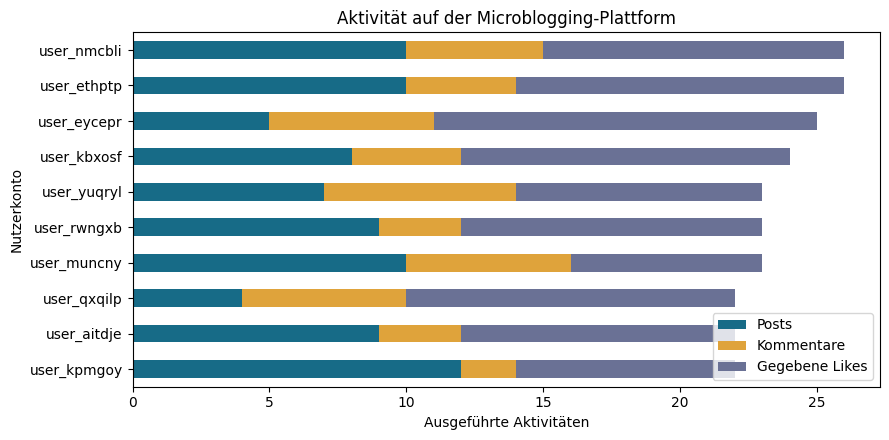

In [4]:
import matplotlib.pyplot as plt
ax = engagement.head(10).sort_values("engagement_score").plot.barh(
    x="username", y=["posts_count", "comments_made", "likes_made"], stacked=True,
    color=["#176B87", "#DFA33B", "#6A7195"], figsize=(9, 4.5))
ax.set(title="Aktivität auf der Microblogging-Plattform", xlabel="Ausgeführte Aktivitäten", ylabel="Nutzerkonto")
ax.legend(["Posts", "Kommentare", "Gegebene Likes"], loc="lower right")
plt.tight_layout()
plt.show()

## Q2 · Welche Posts erhalten Likes? — Vertiefung

Der `LEFT JOIN` erhält Posts ohne Likes. `COUNT(l.like_id)` zählt tatsächliche Likes; `COUNT(*)` würde bei einem Post ohne Like trotzdem die erhaltene Join-Zeile zählen.

In [5]:
sql_q2 = """
SELECT p.post_id, u.username AS author, DATE(p.created_at) AS day,
       COUNT(l.like_id) AS like_count, SUBSTR(p.text, 1, 80) AS preview
FROM posts p JOIN users u ON u.user_id = p.user_id
LEFT JOIN likes l ON l.post_id = p.post_id
GROUP BY p.post_id, u.username, p.created_at, p.text
ORDER BY like_count DESC, p.post_id;
"""
popular_posts = query(DB_PATH, sql_q2)
display(popular_posts.head(10))
assert len(popular_posts) == 865
assert popular_posts["like_count"].sum() == 1266

,post_id,author,day,like_count,preview
0,136,user_ywemfk,2025-08-16,4,Sqlite ai trend sqlite post.
1,138,user_ywemfk,2025-08-26,4,Cloud ai social coffee trend post social post data nlp music trend coffee ml.
2,184,user_nroycw,2025-08-13,4,Data tinyflux social ai nlp sqlite.
3,291,user_djdfki,2025-08-26,4,Tinyflux post cloud neo4j social ai tinyflux nlp social post ai ml tinyflux coff
4,292,user_djdfki,2025-09-05,4,Ml post coffee like post sql data follow python sqlite ml ai cloud ai sqlite.
5,293,user_djdfki,2025-08-26,4,Trend follow mongodb nlp mongodb follow cloud sqlite sqlite cloud coffee.
6,336,user_zjquqt,2025-08-31,4,Cloud post post follow music cloud graph ai tinyflux social.
7,381,user_iwshay,2025-08-23,4,Sql ai sqlite sql sqlite post post.
8,384,user_gkogms,2025-08-15,4,Sql cloud graph ml coffee cloud nlp data.
9,386,user_ucfrhp,2025-09-10,4,Graph follow neo4j follow sqlite sqlite follow sqlite coffee mongodb trend coffe


## Q3 · Follower, Following und ein gerichteter Pfad — Vertiefung

`src_user_id → dst_user_id` bedeutet: Die erste Person folgt der zweiten. Eingehende und ausgehende Beziehungen werden getrennt gezählt.

In [6]:
sql_degrees = """
WITH incoming AS (
    SELECT dst_user_id AS user_id, COUNT(*) AS followers FROM follows GROUP BY dst_user_id
), outgoing AS (
    SELECT src_user_id AS user_id, COUNT(*) AS following FROM follows GROUP BY src_user_id
)
SELECT u.user_id, u.username, COALESCE(i.followers,0) AS followers,
       COALESCE(o.following,0) AS following
FROM users u LEFT JOIN incoming i ON i.user_id=u.user_id
LEFT JOIN outgoing o ON o.user_id=u.user_id
ORDER BY followers DESC, following DESC, u.user_id;
"""
degrees = query(DB_PATH, sql_degrees)
display(degrees.head(10))
assert degrees["followers"].sum() == degrees["following"].sum() == 3047

,user_id,username,followers,following
0,80,user_mgjpzs,27,23
1,90,user_gkogms,25,23
2,98,user_cbmprd,25,23
3,141,user_ticzdz,25,5
4,154,user_oucwdj,24,25
5,41,user_nroycw,22,22
6,71,user_kfkxps,22,22
7,108,user_afrwpa,22,22
8,91,user_ucfrhp,22,9
9,10,user_rfitbv,21,22


Die festen Personen **1 und 3** liefern im mitgelieferten Bestand einen nachvollziehbaren Pfad. Die rekursive CTE sucht gerichtete, zyklenfreie Pfade bis zur konfigurierten Tiefe.
Die Trennzeichen im Pfad verhindern Verwechslungen von IDs wie 1 und 11 und erfassen auch den Startknoten bei der Zyklusprüfung.

Ein leeres Ergebnis bedeutet nur: kein Pfad **innerhalb dieser Suchtiefe**. Die Abfrage ist eine begrenzte Lehrdemonstration; viele mögliche Pfade können schnell teuer werden.

In [7]:
sql_path = """
WITH RECURSIVE frontier(user_id, depth, path) AS (
    SELECT :src, 0, '/' || :src || '/'
    UNION ALL
    SELECT f.dst_user_id, x.depth + 1, x.path || f.dst_user_id || '/'
    FROM frontier x JOIN follows f ON f.src_user_id=x.user_id
    WHERE x.depth < :max_depth AND x.user_id <> :dst
      AND INSTR(x.path, '/' || f.dst_user_id || '/') = 0
)
SELECT user_id, depth, path FROM frontier WHERE user_id=:dst
ORDER BY depth, path LIMIT 1;
"""
path_parameters = {"src":1, "dst":3, "max_depth":3}
path_result = query(DB_PATH, sql_path, path_parameters)
display(path_result)
assert int(path_result.iloc[0]["depth"]) == 2

,user_id,depth,path
0,3,2,/1/2/3/


## Q4 · Posts pro Kalendertag — Vertiefung

Das Fenster stammt aus den Daten, **12. August bis 10. September 2025**. Der Kalender ergänzt fehlende Tage mit null Posts. Erst dadurch bedeuten sieben Zeilen auch sieben aufeinanderfolgende Tage. Am Beginn verwendet der gleitende Durchschnitt die bereits verfügbaren Tage (1 bis 7).

Hier stammen Tageszählung, Nullergänzung und gleitender Durchschnitt aus SQL. pandas und matplotlib stellen das Ergebnis dar.

In [8]:
sql_trend = """
WITH RECURSIVE calendar(day) AS (
    SELECT DATE(MIN(created_at)) FROM posts
    UNION ALL SELECT DATE(day, '+1 day') FROM calendar
    WHERE day < (SELECT DATE(MAX(created_at)) FROM posts)
), daily AS (
    SELECT DATE(created_at) AS day, COUNT(*) AS posts FROM posts GROUP BY DATE(created_at)
), filled AS (
    SELECT calendar.day, COALESCE(daily.posts, 0) AS posts
    FROM calendar LEFT JOIN daily ON daily.day=calendar.day
)
SELECT day, posts,
       AVG(posts) OVER (ORDER BY day ROWS BETWEEN 6 PRECEDING AND CURRENT ROW) AS rolling_7d
FROM filled ORDER BY day;
"""
trend = query(DB_PATH, sql_trend)
display(trend.head(8))
assert len(trend) == 30 and trend["posts"].sum() == 865

,day,posts,rolling_7d
0,2025-08-12,22,22.000000
1,2025-08-13,24,23.000000
2,2025-08-14,31,25.666667
3,2025-08-15,39,29.000000
4,2025-08-16,31,29.400000
5,2025-08-17,28,29.166667
6,2025-08-18,38,30.428571
7,2025-08-19,23,30.571429


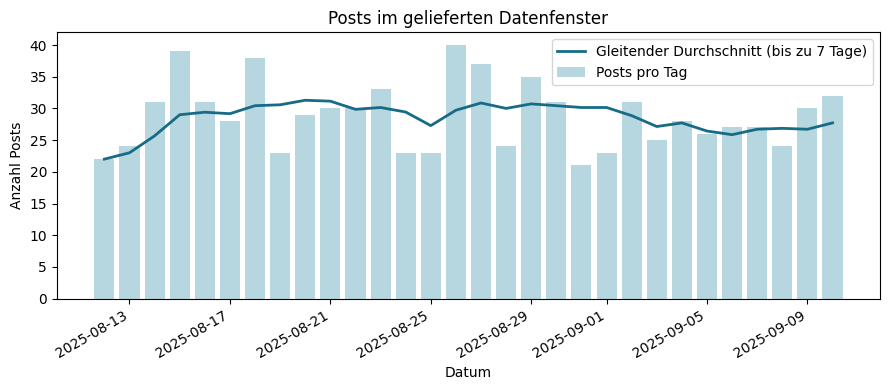

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
dates = pd.to_datetime(trend["day"])
ax.bar(dates, trend["posts"], color="#B6D7DF", label="Posts pro Tag")
ax.plot(dates, trend["rolling_7d"], color="#176B87", linewidth=2, label="Gleitender Durchschnitt (bis zu 7 Tage)")
ax.set(title="Posts im gelieferten Datenfenster", xlabel="Datum", ylabel="Anzahl Posts")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Q5 · Welche Beiträge kommen in den Feed? — Kernabfrage

Wir betrachten Nutzer **1**, die letzten **drei Kalendertage des Post-Bestands** und nur Follow-Beziehungen, die bereits zu Beginn dieses Fensters bestanden. Der Bestand enthält keine Unfollow-Historie; daraus rekonstruieren wir keinen vollständigen historischen Feed.

Das Intervall ist **[since, until)**: Beginn eingeschlossen, Ende ausgeschlossen. Das heutige Systemdatum spielt keine Rolle. Auf den ISO-Zeitstempeln steht keine SQL-Datumsfunktion im Filter; so kann der Index `(user_id, created_at)` auch den Zeitbereich unterstützen.

In [10]:
last_day = pd.Timestamp(query(DB_PATH, "SELECT DATE(MAX(created_at)) AS day FROM posts").iloc[0]["day"])
until = last_day + pd.Timedelta(days=1)
since = until - pd.Timedelta(days=3)
feed_parameters = {"viewer": 1, "since": since.isoformat(), "until": until.isoformat()}
print(feed_parameters)
sql_feed = """
SELECT p.post_id, u.username AS author, p.created_at,
       SUBSTR(p.text, 1, 100) AS preview,
       (SELECT COUNT(*) FROM likes l WHERE l.post_id=p.post_id) AS like_count
FROM follows f JOIN posts p ON p.user_id=f.dst_user_id
JOIN users u ON u.user_id=p.user_id
WHERE f.src_user_id=:viewer AND f.since <= :since
  AND p.created_at >= :since AND p.created_at < :until
ORDER BY p.created_at DESC, p.post_id
LIMIT 50;
"""
feed = query(DB_PATH, sql_feed, feed_parameters)
display(feed.head(20))
assert not feed.empty

{'viewer': 1, 'since': '2025-09-08T00:00:00', 'until': '2025-09-11T00:00:00'}


,post_id,author,created_at,preview,like_count
0,23,user_jigbld,2025-09-10T00:00:00,Mongodb sqlite nlp neo4j cloud social coffee sql graph data stream ml stream data sql.,2
1,399,user_ethptp,2025-09-10T00:00:00,Cloud neo4j graph ml python like.,0
2,204,user_lhauqg,2025-09-09T00:00:00,Mongodb social mongodb mongodb graph follow trend data trend.,3
3,396,user_ethptp,2025-09-08T00:00:00,Social like neo4j graph tinyflux python.,0


## Indexblick — Vertiefung

Untersuche **dieselbe** Feed-Abfrage mit denselben Parametern. Wo erscheinen `SEARCH` und der zusammengesetzte Index? Ein zusätzliches Sortieren kann trotzdem nötig sein.
`EXPLAIN QUERY PLAN` beschreibt einen Ausführungsplan; es misst keine Beschleunigung. Pläne können sich je nach SQLite-Version und Daten ändern. Aus diesem kleinen Bestand folgt keine allgemeine Produktrangliste. [SQLite: EXPLAIN QUERY PLAN](https://www.sqlite.org/eqp.html).

In [11]:
display(query(DB_PATH, "EXPLAIN QUERY PLAN " + sql_feed, feed_parameters))

,id,parent,notused,detail
0,9,0,62,SEARCH f USING INDEX sqlite_autoindex_follows_1 (src_user_id=?)
1,18,0,45,SEARCH u USING INTEGER PRIMARY KEY (rowid=?)
2,24,0,49,SEARCH p USING INDEX idx_posts_user_created (user_id=? AND created_at>? AND created_at<?)
3,49,0,0,CORRELATED SCALAR SUBQUERY 1
4,54,49,53,SEARCH l USING COVERING INDEX idx_likes_post (post_id=?)
5,69,0,0,USE TEMP B-TREE FOR ORDER BY


## Transfer zur UAP-Aufgabe

- Welche ID identifiziert eine Zeile, welche nur eine Bezeichnung aus einer Quelle?
- Wo brauchst Du eine Zwischentabelle und `COUNT(DISTINCT ...)`?
- Welche Datenregeln kann die Datenbank erzwingen, welche fachliche Aussage muss ein Mensch prüfen?

Weiter mit [Aufgabe 1: UAP-Katalog in SQLite](../../tasks/01_sqlite/task.ipynb).
Die Datei unter `data/work/microblogging/storage.sqlite` bleibt nach dem Schliessen des Notebooks erhalten.